# 아산시 돌봄 데이터 EDA & 시각화

`merge.ipynb` 실행 후 생성된 마스터 테이블 기반으로 현황을 파악합니다.

| 분석 | 마스터 | 핵심 질문 |
|---|---|---|
| 읍면동별 고령화 현황 | A | 어디가 가장 늙었나? 속도는? |
| 장기요양 등급 추이 | B | 수요가 얼마나 빨리 늘고 있나? |
| 시설 접근성 갭 | A | 인구 대비 시설이 부족한 곳은? |
| 인구구조 변화 | A+C | 생산가능인구 감소 vs 고령인구 증가 |

## 0. 환경 설정

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import font_manager, rc
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# 한글 폰트 설정 (Windows)
font_path = 'C:/Windows/Fonts/malgun.ttf'
font_manager.fontManager.addfont(font_path)
rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 경로
DATA_DIR = Path(r'C:\Users\HP\IdeaProjects\sundo\asan_care\asan_care\데이터')
MASTER_DIR = DATA_DIR.parent / 'master'
EDA_DIR = DATA_DIR.parent / 'eda'
EDA_DIR.mkdir(exist_ok=True)

print(f'마스터 경로: {MASTER_DIR}')
print(f'EDA 출력:   {EDA_DIR}')

마스터 경로: C:\Users\HP\IdeaProjects\sundo\asan_care\asan_care\master
EDA 출력:   C:\Users\HP\IdeaProjects\sundo\asan_care\asan_care\eda


In [2]:
# ── 마스터 테이블 로딩 ──
ma = pd.read_csv(MASTER_DIR / 'master_a_읍면동.csv', encoding='cp949')
mb = pd.read_csv(MASTER_DIR / 'master_b_아산시_시계열.csv', encoding='cp949')
mc = pd.read_csv(MASTER_DIR / 'master_c_충남_전망.csv', encoding='cp949')

print(f'마스터 A (읍면동):    {ma.shape}')
print(f'마스터 B (시계열):    {mb.shape}')
print(f'마스터 C (전망):      {mc.shape}')

latest_year = ma['연도'].max()
ma_latest = ma[ma['연도'] == latest_year].copy()
print(f'\n기준 연도: {latest_year}')

마스터 A (읍면동):    (68, 16)
마스터 B (시계열):    (11, 17)
마스터 C (전망):      (39, 8)

기준 연도: 2024


---
## 1. 읍면동별 고령화 현황

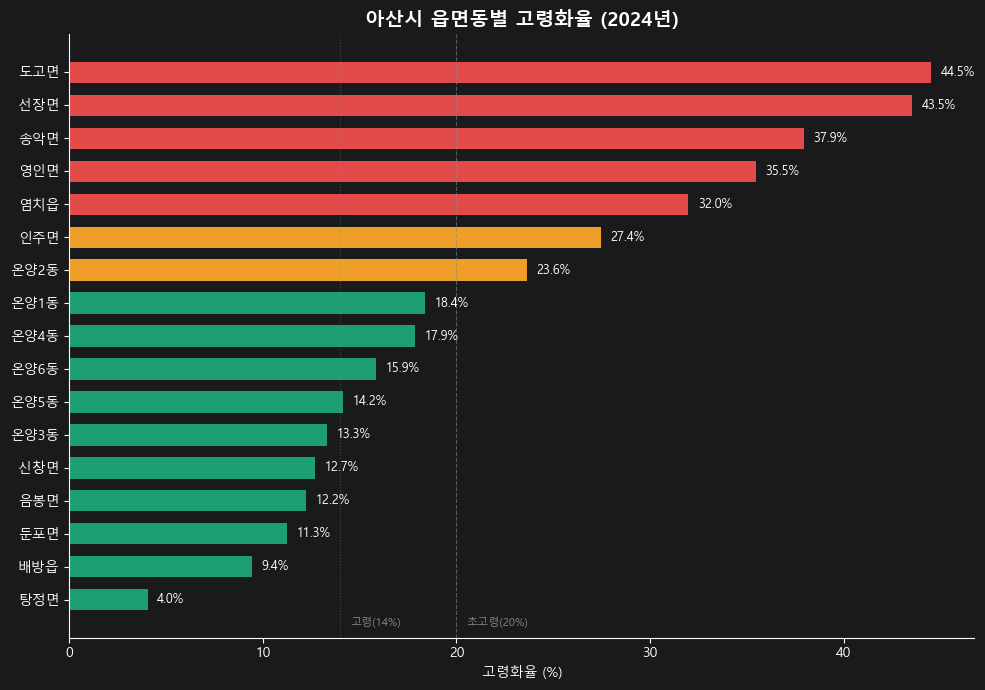

In [3]:
# ── 1-1. 고령화율 바차트 (최신 연도) ──
df = ma_latest.sort_values('고령화율', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#E24B4A' if v >= 30 else '#EF9F27' if v >= 20 else '#1D9E75' for v in df['고령화율']]
bars = ax.barh(df['읍면동'], df['고령화율'], color=colors, height=0.65)

# 기준선
ax.axvline(x=20, color='#888', ls='--', lw=0.8, alpha=0.6)
ax.axvline(x=14, color='#888', ls=':', lw=0.8, alpha=0.4)
ax.text(20.5, -0.8, '초고령(20%)', fontsize=8, color='#888')
ax.text(14.5, -0.8, '고령(14%)', fontsize=8, color='#888')

# 값 표시
for bar, val in zip(bars, df['고령화율']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)

ax.set_xlabel('고령화율 (%)')
ax.set_title(f'아산시 읍면동별 고령화율 ({latest_year}년)', fontsize=14, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(EDA_DIR / '1_1_고령화율_바차트.png', dpi=150, bbox_inches='tight')
plt.show()

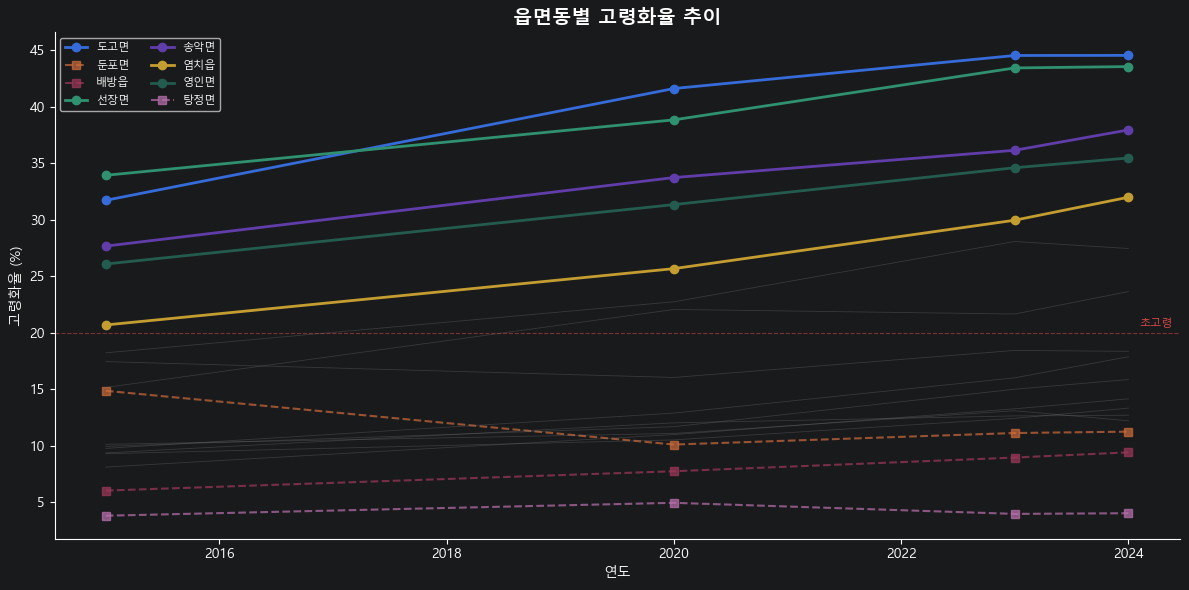

In [4]:
# ── 1-2. 고령화율 변화 추이 (읍면동별) ──
fig, ax = plt.subplots(figsize=(12, 6))

# 고령화율 높은 순 5개 + 낮은 순 3개
top = ma_latest.nlargest(5, '고령화율')['읍면동'].tolist()
bot = ma_latest.nsmallest(3, '고령화율')['읍면동'].tolist()
highlight = top + bot

for dong in ma['읍면동'].unique():
    sub = ma[ma['읍면동'] == dong].sort_values('연도')
    if dong in top:
        ax.plot(sub['연도'], sub['고령화율'], 'o-', lw=2, label=dong)
    elif dong in bot:
        ax.plot(sub['연도'], sub['고령화율'], 's--', lw=1.5, alpha=0.7, label=dong)
    else:
        ax.plot(sub['연도'], sub['고령화율'], '-', lw=0.6, alpha=0.3, color='gray')

ax.axhline(y=20, color='#E24B4A', ls='--', lw=0.8, alpha=0.5)
ax.text(ma['연도'].max() + 0.1, 20.5, '초고령', fontsize=8, color='#E24B4A')
ax.set_xlabel('연도')
ax.set_ylabel('고령화율 (%)')
ax.set_title('읍면동별 고령화율 추이', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(EDA_DIR / '1_2_고령화율_추이.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# ── 1-3. 인구구조 요약 테이블 ──
summary = ma_latest[[
    '읍면동', '총인구', '유소년인구', '생산가능인구', '고령인구',
    '고령화율', '고령화지수', '노년부양비'
]].sort_values('고령화율', ascending=False).reset_index(drop=True)

# 아산시 전체 합계 행 추가
total = summary.select_dtypes(include='number').sum()
total['고령화율'] = (total['고령인구'] / total['총인구'] * 100).round(2)
total['고령화지수'] = (total['고령인구'] / total['유소년인구'] * 100).round(1)
total['노년부양비'] = (total['고령인구'] / total['생산가능인구'] * 100).round(1)
total_row = pd.DataFrame([['아산시 전체'] + total.tolist()], columns=summary.columns)
summary = pd.concat([summary, total_row], ignore_index=True)

print(f'=== {latest_year}년 읍면동별 인구구조 ===')
summary

=== 2024년 읍면동별 인구구조 ===


,읍면동,총인구,유소년인구,생산가능인구,고령인구,고령화율,고령화지수,노년부양비
0,도고면,4533.0,145.0,2370.0,2018.0,44.52,1391.7,85.1
1,선장면,3159.0,64.0,1720.0,1375.0,43.53,2148.4,79.9
2,송악면,3860.0,248.0,2148.0,1464.0,37.93,590.3,68.2
3,영인면,6084.0,229.0,3698.0,2157.0,35.45,941.9,58.3
4,염치읍,5851.0,346.0,3634.0,1871.0,31.98,540.8,51.5
5,인주면,6753.0,297.0,4602.0,1854.0,27.45,624.2,40.3
6,온양2동,11852.0,635.0,8415.0,2802.0,23.64,441.3,33.3
7,온양1동,10023.0,1066.0,7117.0,1840.0,18.36,172.6,25.9
8,온양4동,18263.0,2002.0,12995.0,3266.0,17.88,163.1,25.1
9,온양6동,26363.0,3671.0,18509.0,4183.0,15.87,113.9,22.6


---
## 2. 장기요양 등급 추이

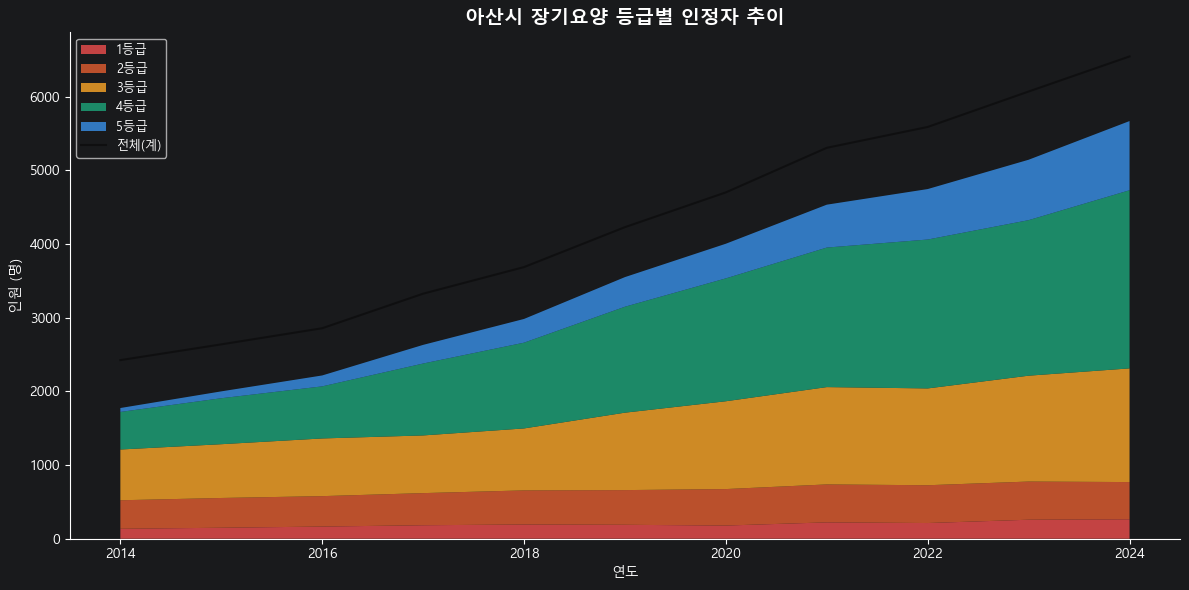

In [6]:
# ── 2-1. 등급별 인원 추이 (누적 영역) ──
grade_cols = [c for c in mb.columns if c.startswith('요양_') and c != '요양_계']
# 등급외, 인지지원등급 제외하고 1~5등급만
grade_main = [c for c in grade_cols if any(f'{i}등급' in c for i in range(1, 6))]

fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#E24B4A', '#D85A30', '#EF9F27', '#1D9E75', '#378ADD']
labels = [c.replace('요양_', '') for c in grade_main]

ax.stackplot(mb['연도'], *[mb[c].fillna(0) for c in grade_main],
             labels=labels, colors=colors, alpha=0.85)

# 전체 계 라인
ax.plot(mb['연도'], mb['요양_계'].fillna(0), 'k-', lw=1.5, alpha=0.4, label='전체(계)')

ax.set_xlabel('연도')
ax.set_ylabel('인원 (명)')
ax.set_title('아산시 장기요양 등급별 인정자 추이', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(EDA_DIR / '2_1_장기요양_등급추이.png', dpi=150, bbox_inches='tight')
plt.show()

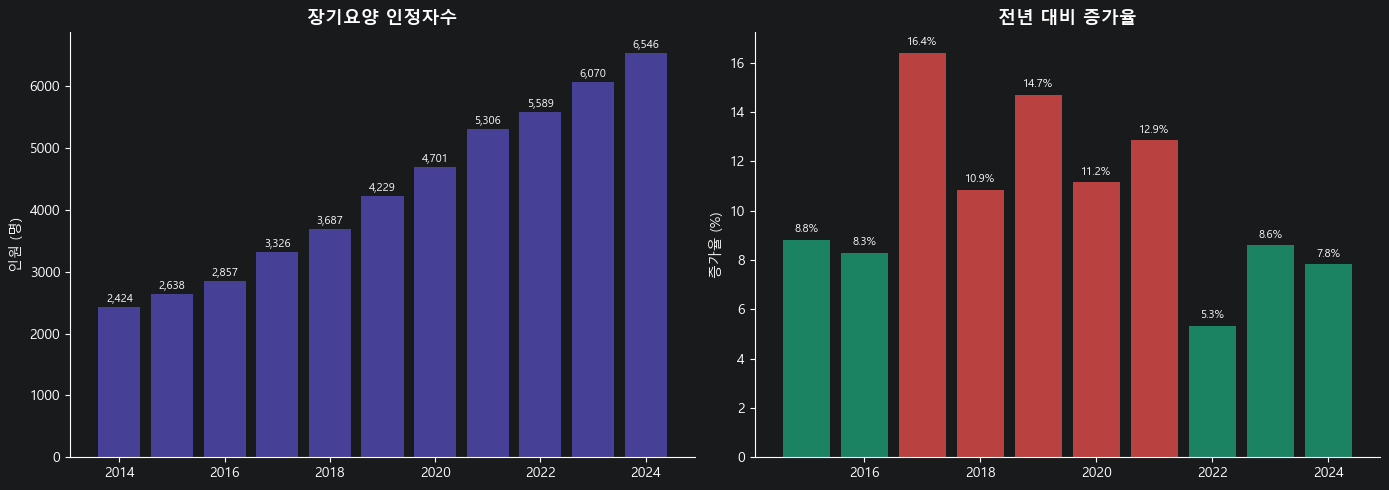

In [7]:
# ── 2-2. 연도별 증가율 ──
mb_valid = mb.dropna(subset=['요양_계']).copy()
mb_valid['전년대비_증가율'] = mb_valid['요양_계'].pct_change() * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 절대값
ax1.bar(mb_valid['연도'], mb_valid['요양_계'], color='#534AB7', alpha=0.8)
for _, row in mb_valid.iterrows():
    ax1.text(row['연도'], row['요양_계'] + 80, f"{int(row['요양_계']):,}",
             ha='center', fontsize=8)
ax1.set_title('장기요양 인정자수', fontsize=13, fontweight='bold')
ax1.set_ylabel('인원 (명)')
ax1.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax1.spines[['top', 'right']].set_visible(False)

# 증가율
ax2.bar(mb_valid['연도'].iloc[1:], mb_valid['전년대비_증가율'].iloc[1:],
        color=['#E24B4A' if v > 10 else '#1D9E75' for v in mb_valid['전년대비_증가율'].iloc[1:]],
        alpha=0.8)
for _, row in mb_valid.iloc[1:].iterrows():
    ax2.text(row['연도'], row['전년대비_증가율'] + 0.3,
             f"{row['전년대비_증가율']:.1f}%", ha='center', fontsize=8)
ax2.set_title('전년 대비 증가율', fontsize=13, fontweight='bold')
ax2.set_ylabel('증가율 (%)')
ax2.axhline(0, color='gray', lw=0.5)
ax2.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(EDA_DIR / '2_2_요양_증가율.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. 시설 접근성 갭

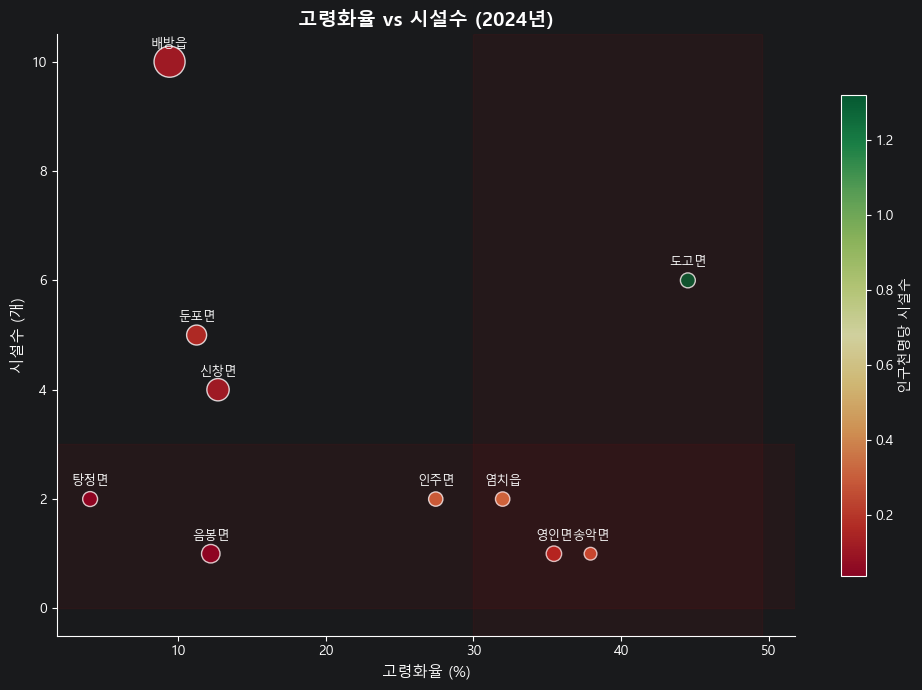

In [8]:
# ── 3-1. 고령화율 vs 시설수 산점도 ──
df = ma_latest.dropna(subset=['시설_합계']).copy()

fig, ax = plt.subplots(figsize=(10, 7))

sizes = df['고령인구'] / df['고령인구'].max() * 500
scatter = ax.scatter(df['고령화율'], df['시설_합계'], s=sizes,
                     c=df['인구천명당_시설수'], cmap='RdYlGn', alpha=0.8,
                     edgecolors='white', linewidth=1)

# 라벨
for _, row in df.iterrows():
    ax.annotate(row['읍면동'], (row['고령화율'], row['시설_합계']),
                fontsize=9, ha='center', va='bottom',
                xytext=(0, 8), textcoords='offset points')

plt.colorbar(scatter, ax=ax, label='인구천명당 시설수', shrink=0.8)
ax.set_xlabel('고령화율 (%)', fontsize=11)
ax.set_ylabel('시설수 (개)', fontsize=11)
ax.set_title(f'고령화율 vs 시설수 ({latest_year}년)', fontsize=14, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

# 사각지대 영역 표시 (고령화율 높고 시설 적은 곳)
ax.axvspan(30, df['고령화율'].max() + 5, alpha=0.05, color='red')
ax.axhspan(0, 3, alpha=0.05, color='red')

plt.tight_layout()
plt.savefig(EDA_DIR / '3_1_고령화_시설_산점도.png', dpi=150, bbox_inches='tight')
plt.show()

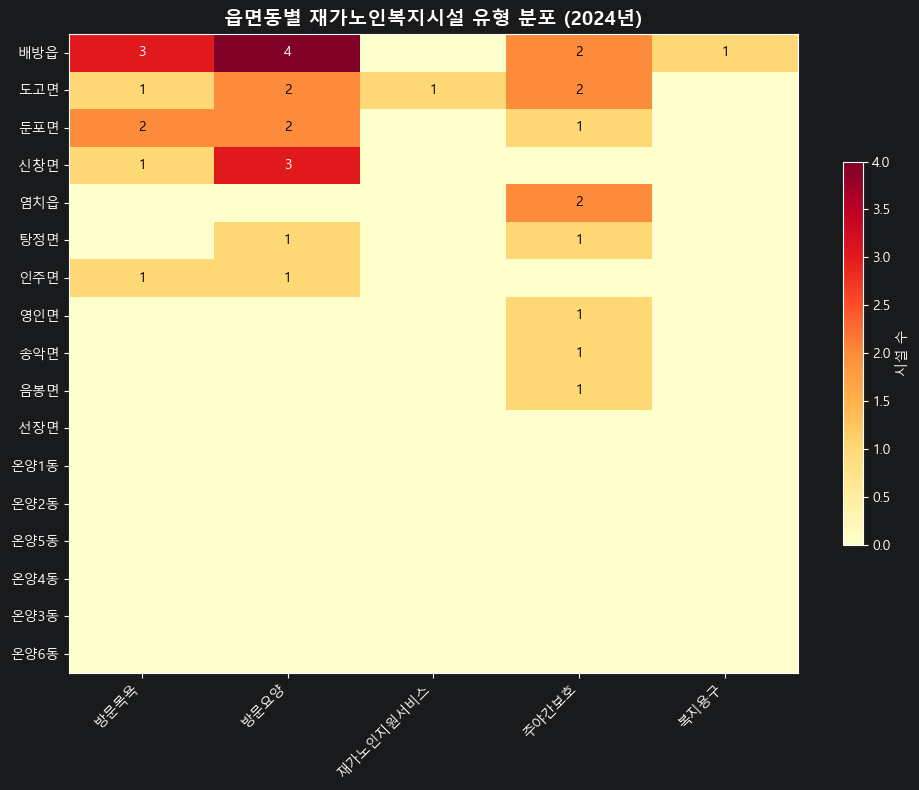

In [9]:
# ── 3-2. 시설 유형별 분포 (읍면동별 히트맵) ──
fac_cols = [c for c in ma_latest.columns if c.startswith('시설_') and c != '시설_합계']
heatmap_data = ma_latest.set_index('읍면동')[fac_cols].fillna(0).astype(int)
heatmap_data.columns = [c.replace('시설_', '') for c in heatmap_data.columns]
heatmap_data = heatmap_data.loc[heatmap_data.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(heatmap_data.values, cmap='YlOrRd', aspect='auto')

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, rotation=45, ha='right')
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

# 값 표시
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        val = heatmap_data.iloc[i, j]
        if val > 0:
            color = 'white' if val > heatmap_data.values.max() * 0.6 else 'black'
            ax.text(j, i, str(val), ha='center', va='center', fontsize=10, color=color)

ax.set_title(f'읍면동별 재가노인복지시설 유형 분포 ({latest_year}년)', fontsize=14, fontweight='bold')
plt.colorbar(im, ax=ax, label='시설 수', shrink=0.6)
plt.tight_layout()
plt.savefig(EDA_DIR / '3_2_시설유형_히트맵.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. 인구구조 변화 & 충남 전망

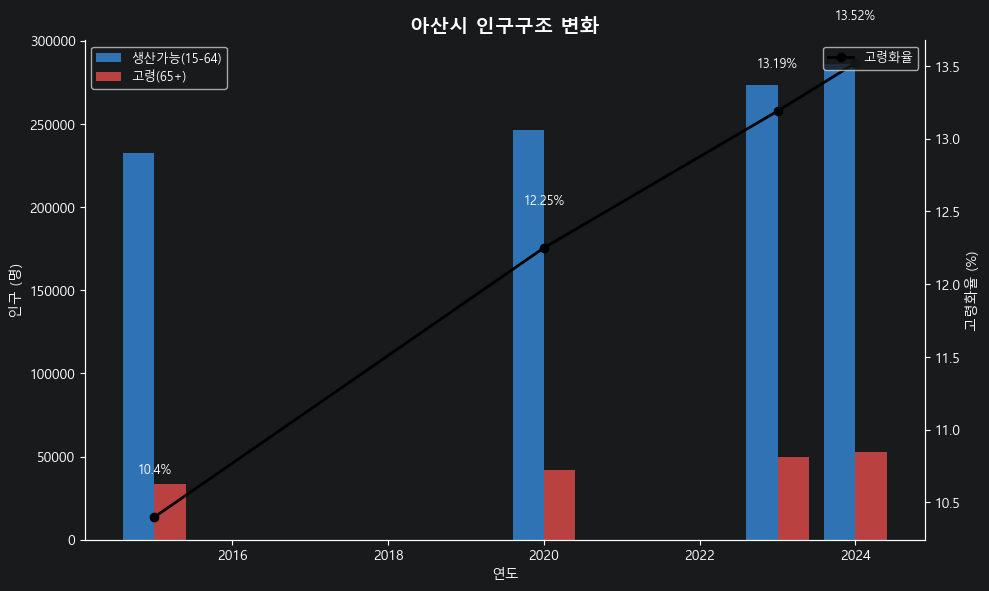

In [10]:
# ── 4-1. 아산시 인구구조 변화 (마스터 B) ──
mb_valid = mb.dropna(subset=['총인구']).copy()

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(mb_valid['연도'] - 0.2, mb_valid['생산가능인구'], width=0.4,
       label='생산가능(15-64)', color='#378ADD', alpha=0.8)
ax.bar(mb_valid['연도'] + 0.2, mb_valid['고령인구'], width=0.4,
       label='고령(65+)', color='#E24B4A', alpha=0.8)

ax2 = ax.twinx()
ax2.plot(mb_valid['연도'], mb_valid['고령화율'], 'ko-', lw=2, markersize=6, label='고령화율')
for _, row in mb_valid.iterrows():
    ax2.text(row['연도'], row['고령화율'] + 0.3, f"{row['고령화율']}%",
             ha='center', fontsize=9)

ax.set_xlabel('연도')
ax.set_ylabel('인구 (명)')
ax2.set_ylabel('고령화율 (%)')
ax.set_title('아산시 인구구조 변화', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax2.legend(loc='upper right', fontsize=9)
ax.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig(EDA_DIR / '4_1_인구구조_변화.png', dpi=150, bbox_inches='tight')
plt.show()

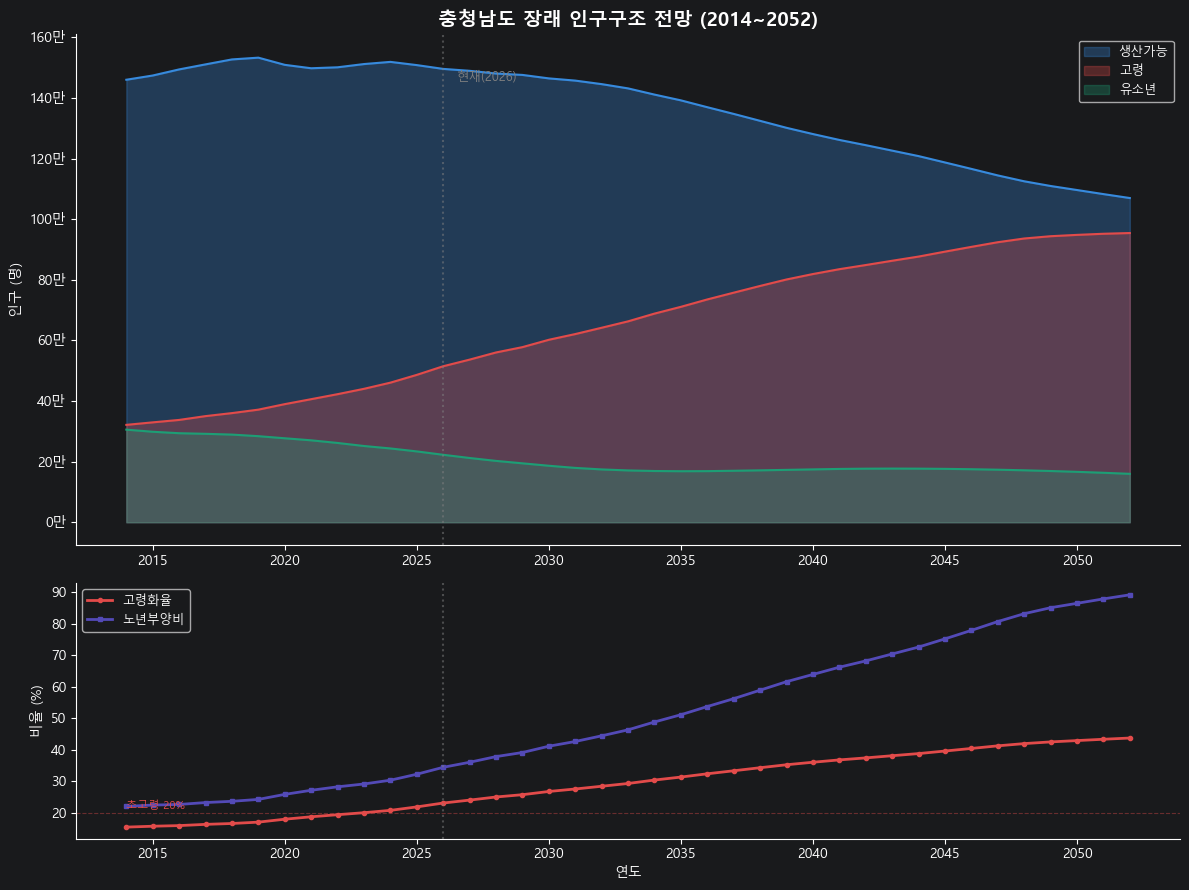

In [11]:
# ── 4-2. 충남 장래 고령화율 전망 ──
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), gridspec_kw={'height_ratios': [2, 1]})

# 상단: 인구 추이
ax1.fill_between(mc['연도'], mc['생산가능인구_추계'], alpha=0.3, color='#378ADD', label='생산가능')
ax1.fill_between(mc['연도'], mc['고령인구_추계'], alpha=0.3, color='#E24B4A', label='고령')
ax1.fill_between(mc['연도'], mc['유소년인구_추계'], alpha=0.3, color='#1D9E75', label='유소년')
ax1.plot(mc['연도'], mc['생산가능인구_추계'], color='#378ADD', lw=1.5)
ax1.plot(mc['연도'], mc['고령인구_추계'], color='#E24B4A', lw=1.5)
ax1.plot(mc['연도'], mc['유소년인구_추계'], color='#1D9E75', lw=1.5)
ax1.axvline(x=2026, color='gray', ls=':', alpha=0.5)
ax1.text(2026.5, mc['생산가능인구_추계'].max() * 0.95, '현재(2026)', fontsize=9, color='gray')
ax1.set_ylabel('인구 (명)')
ax1.set_title('충청남도 장래 인구구조 전망 (2014~2052)', fontsize=14, fontweight='bold')
ax1.legend(fontsize=9)
ax1.spines[['top', 'right']].set_visible(False)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/10000:.0f}만'))

# 하단: 고령화율 + 노년부양비
ax2.plot(mc['연도'], mc['고령화율_추계'], 'o-', color='#E24B4A', lw=2, markersize=3, label='고령화율')
ax2.plot(mc['연도'], mc['노년부양비_추계'], 's-', color='#534AB7', lw=2, markersize=3, label='노년부양비')
ax2.axhline(y=20, color='#E24B4A', ls='--', lw=0.8, alpha=0.4)
ax2.text(2014, 21, '초고령 20%', fontsize=8, color='#E24B4A')
ax2.axvline(x=2026, color='gray', ls=':', alpha=0.5)
ax2.set_xlabel('연도')
ax2.set_ylabel('비율 (%)')
ax2.legend(fontsize=9)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(EDA_DIR / '4_2_충남_장래전망.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. EDA 요약 통계 저장

In [12]:
# ── 요약 테이블 저장 ──

# 5-1. 읍면동별 핵심 지표 (최신 연도)
eda_summary = ma_latest[[
    '읍면동', '총인구', '유소년인구', '생산가능인구', '고령인구',
    '고령화율', '고령화지수', '노년부양비',
    '시설_합계', '인구천명당_시설수'
]].sort_values('고령화율', ascending=False).reset_index(drop=True)

eda_summary.to_csv(EDA_DIR / 'eda_읍면동_요약.csv', index=False, encoding='cp949')

# 5-2. 장기요양 추이
mb.to_csv(EDA_DIR / 'eda_시계열_요약.csv', index=False, encoding='cp949')

# 5-3. 충남 전망 주요 시점
mc_key = mc[mc['연도'].isin(list(range(2024, 2053, 2)))].copy()
mc_key.to_csv(EDA_DIR / 'eda_충남_전망_주요시점.csv', index=False, encoding='cp949')

print('✓ eda_읍면동_요약.csv')
print('✓ eda_시계열_요약.csv')
print('✓ eda_충남_전망_주요시점.csv')
print(f'\n차트 8개 + CSV 3개 → {EDA_DIR}')

✓ eda_읍면동_요약.csv
✓ eda_시계열_요약.csv
✓ eda_충남_전망_주요시점.csv

차트 8개 + CSV 3개 → C:\Users\HP\IdeaProjects\sundo\asan_care\asan_care\eda
